In [1]:
print("Hello, lipstick effect proyect!")


Hello, lipstick effect proyect!


In [1]:
import os 
os.rename("cosmetic sales.csv","data/cosmetics_sales.csv")

In [2]:
import pandas as pd
df=pd.read_csv("data/cosmetics_sales.csv")
df.head()


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_bt,Business trend indicator,nace_r2,Statistical classification of economic activities in the European Community (NACE Rev. 2),s_adj,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47,"Retail trade, except of motor vehicles and mot...",CA,...,DE,Germany,2005-01,NaN,65.9,NaN,p,provisional,NaN,NaN
1,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47,"Retail trade, except of motor vehicles and mot...",CA,...,DE,Germany,2005-02,NaN,62.4,NaN,p,provisional,NaN,NaN
2,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47,"Retail trade, except of motor vehicles and mot...",CA,...,DE,Germany,2005-03,NaN,72.9,NaN,p,provisional,NaN,NaN
3,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47,"Retail trade, except of motor vehicles and mot...",CA,...,DE,Germany,2005-04,NaN,71.0,NaN,p,provisional,NaN,NaN
4,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47,"Retail trade, except of motor vehicles and mot...",CA,...,DE,Germany,2005-05,NaN,70.5,NaN,p,provisional,NaN,NaN


In [3]:
df('nace_r2').unique()

TypeError: 'DataFrame' object is not callable

In [4]:
df['nace_r2'].unique()

<StringArray>
['G47', 'G47_NF_HLTH']
Length: 2, dtype: str

In [6]:
cosmetics=df[df['nace_r2']=='G47_NF_HLTH']
cosmetics.heaf()

AttributeError: 'DataFrame' object has no attribute 'heaf'

In [7]:
cosmetics=df[df['nace_r2']=='G47_NF_HLTH']
cosmetics.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_bt,Business trend indicator,nace_r2,Statistical classification of economic activities in the European Community (NACE Rev. 2),s_adj,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
3072,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47_NF_HLTH,Dispensing chemist; retail sale of medical and...,CA,...,ES,Spain,2005-01,NaN,90.6,NaN,p,provisional,NaN,NaN
3073,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47_NF_HLTH,Dispensing chemist; retail sale of medical and...,CA,...,ES,Spain,2005-02,NaN,83.4,NaN,p,provisional,NaN,NaN
3074,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47_NF_HLTH,Dispensing chemist; retail sale of medical and...,CA,...,ES,Spain,2005-03,NaN,89.0,NaN,p,provisional,NaN,NaN
3075,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47_NF_HLTH,Dispensing chemist; retail sale of medical and...,CA,...,ES,Spain,2005-04,NaN,85.8,NaN,p,provisional,NaN,NaN
3076,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,NETTUR,Net turnover,G47_NF_HLTH,Dispensing chemist; retail sale of medical and...,CA,...,ES,Spain,2005-05,NaN,89.7,NaN,p,provisional,NaN,NaN


In [8]:
print(cosmetics['geo'].unique())
print(cosmetics['TIME_PERIOD'].min(), "to", cosmetics['TIME_PERIOD'].mac())


<StringArray>
['ES', 'FR', 'IT']
Length: 3, dtype: str


AttributeError: 'Series' object has no attribute 'mac'

In [9]:
print(cosmetics['geo'].unique())
print(cosmetics['TIME_PERIOD'].min(), "to", cosmetics['TIME_PERIOD'].max())

<StringArray>
['ES', 'FR', 'IT']
Length: 3, dtype: str
2005-01 to 2023-12


Matplotlib is building the font cache; this may take a moment.


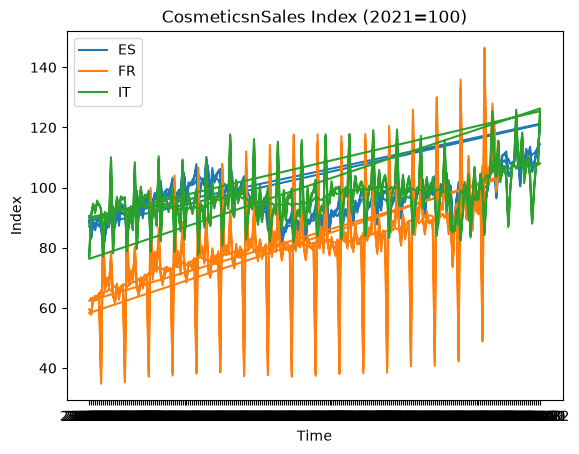

In [10]:
import matplotlib.pyplot as plt
for country in cosmetics['geo'].unique(): 
    subset=cosmetics[cosmetics['geo']==country]
    plt.plot(subset['TIME_PERIOD'], subset['OBS_VALUE'], label=country) 
plt.legend()
plt.title("CosmeticsnSales Index (2021=100)")
plt.xlabel("Time")
plt.ylabel("Index")
plt.show() 

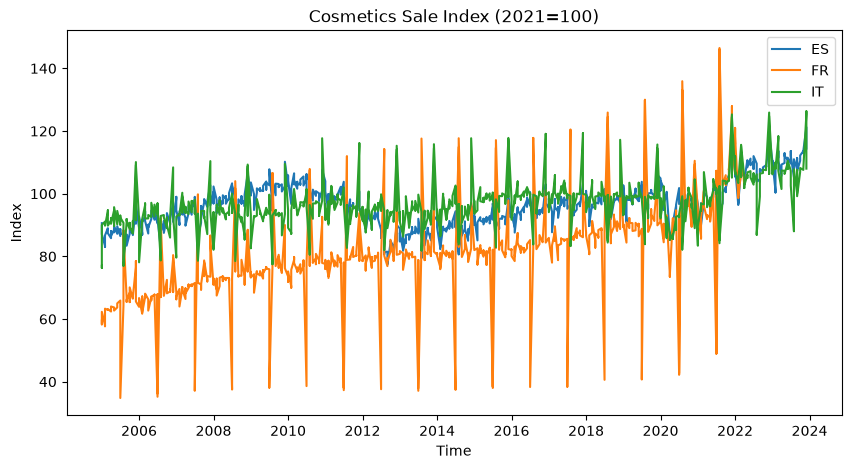

In [11]:
cosmetics=cosmetics.copy()
cosmetics['TIME_PERIOD']=pd.to_datetime(cosmetics['TIME_PERIOD'])
plt.figure(figsize=(10,5))
for country in cosmetics['geo'].unique():
    subset=cosmetics[cosmetics['geo']==country].sort_values('TIME_PERIOD')
    plt.plot(subset['TIME_PERIOD'], subset['OBS_VALUE'], label=country)
plt.legend()
plt.title("Cosmetics Sale Index (2021=100)")
plt.xlabel("Time")
plt.ylabel("Index")
plt.show()

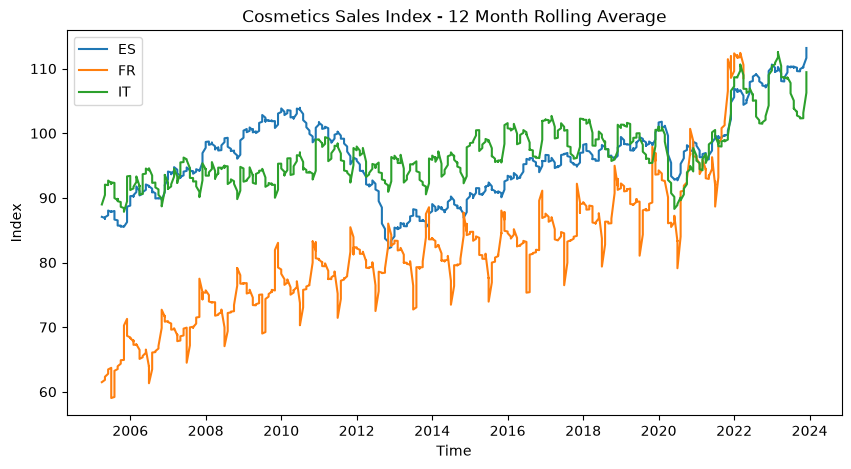

In [13]:
plt.figure(figsize=(10,5))
for country in cosmetics['geo'].unique():
    subset=cosmetics[cosmetics['geo']==country].sort_values('TIME_PERIOD') 
    rolling=subset['OBS_VALUE']. rolling(window=12).mean()
    plt.plot(subset['TIME_PERIOD'], rolling, label=country)
plt.legend()
plt.title("Cosmetics Sales Index - 12 Month Rolling Average")
plt.xlabel("Time")
plt.ylabel("Index")
plt.show() 

In [14]:
unemp=pd.read_csv("data/unemployment.csv")
unemp.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,s_adj,Seasonal adjustment,age,Age class,unit,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:UNE_RT_M(1.0),Unemployment by sex and age - monthly data,M,Monthly,NSA,Unadjusted data (i.e. neither seasonally adjus...,TOTAL,Total,PC_ACT,...,ES,Spain,2005-01,NaN,10.4,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:UNE_RT_M(1.0),Unemployment by sex and age - monthly data,M,Monthly,NSA,Unadjusted data (i.e. neither seasonally adjus...,TOTAL,Total,PC_ACT,...,ES,Spain,2005-02,NaN,10.2,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:UNE_RT_M(1.0),Unemployment by sex and age - monthly data,M,Monthly,NSA,Unadjusted data (i.e. neither seasonally adjus...,TOTAL,Total,PC_ACT,...,ES,Spain,2005-03,NaN,10.0,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:UNE_RT_M(1.0),Unemployment by sex and age - monthly data,M,Monthly,NSA,Unadjusted data (i.e. neither seasonally adjus...,TOTAL,Total,PC_ACT,...,ES,Spain,2005-04,NaN,9.8,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:UNE_RT_M(1.0),Unemployment by sex and age - monthly data,M,Monthly,NSA,Unadjusted data (i.e. neither seasonally adjus...,TOTAL,Total,PC_ACT,...,ES,Spain,2005-05,NaN,9.3,NaN,NaN,NaN,NaN,NaN


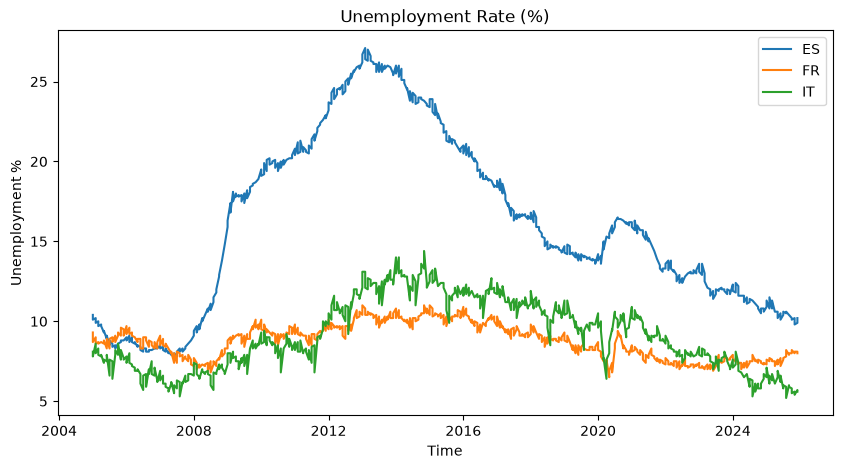

In [15]:
unemp['TIME_PERIOD']=pd.to_datetime(unemp['TIME_PERIOD']) 
plt.figure(figsize=(10,5))
for country in ['ES', 'FR', 'IT']: 
    subset=unemp[unemp['geo']==country].sort_values('TIME_PERIOD') 
    plt.plot(subset['TIME_PERIOD'], subset['OBS_VALUE'], label=country) 
plt.legend()
plt.title("Unemployment Rate (%)") 
plt.xlabel("Time")
plt.ylabel("Unemployment %") 
plt.show() 

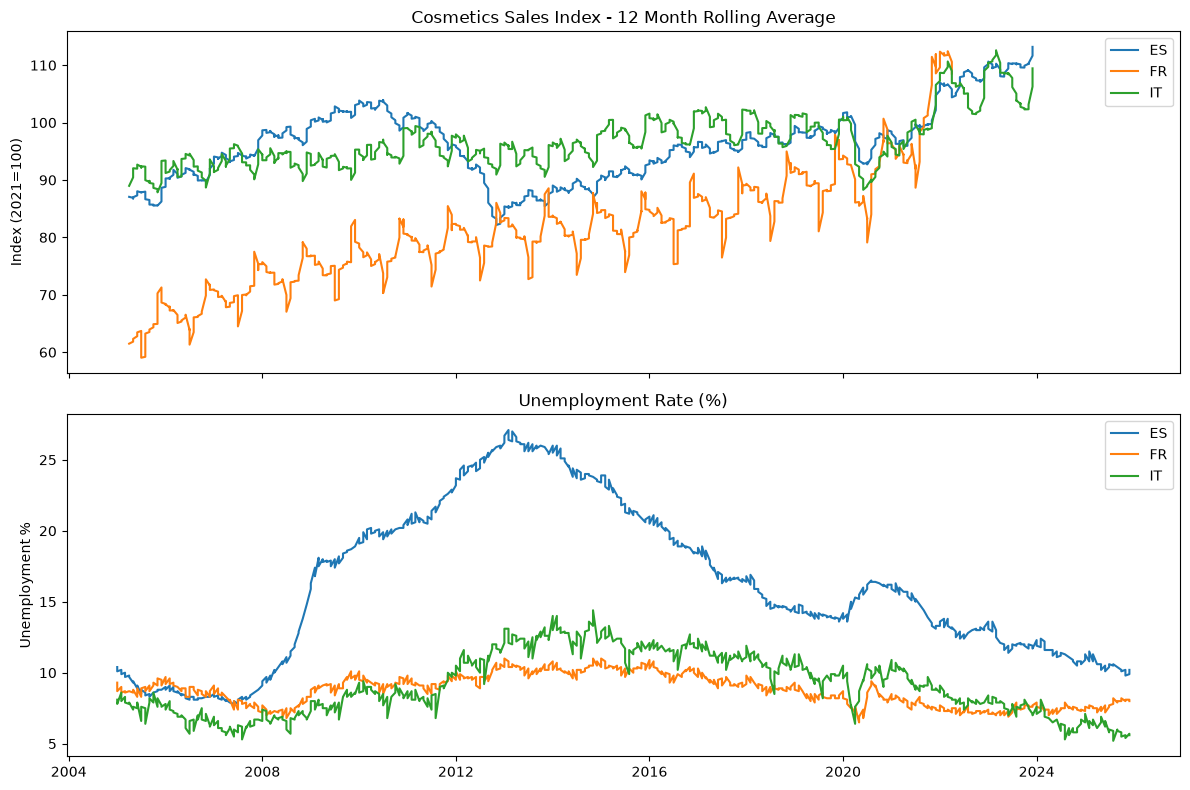

In [16]:
fig, (ax1, ax2)=plt.subplots(2, 1, figsize=(12,8), sharex=True)
#Top chart: cosmetics sales
for country in cosmetics['geo'].unique(): 
    subset=cosmetics[cosmetics['geo']==country].sort_values('TIME_PERIOD') 
    rolling=subset['OBS_VALUE'].rolling(window=12).mean()
    ax1.plot(subset['TIME_PERIOD'], rolling,label=country) 
ax1.set_title("Cosmetics Sales Index - 12 Month Rolling Average") 
ax1.set_ylabel("Index (2021=100)")
ax1.legend() 

#Bottom chart:unemployment
for country in ['ES', 'FR', 'IT']:
    subset=unemp[unemp['geo']==country].sort_values('TIME_PERIOD')
    ax2.plot(subset['TIME_PERIOD'], subset['OBS_VALUE'], label=country)
ax2.set_title("Unemployment Rate (%)")
ax2.set_ylabel("Unemployment %")
ax2.legend()

plt.tight_layout()
plt.show()

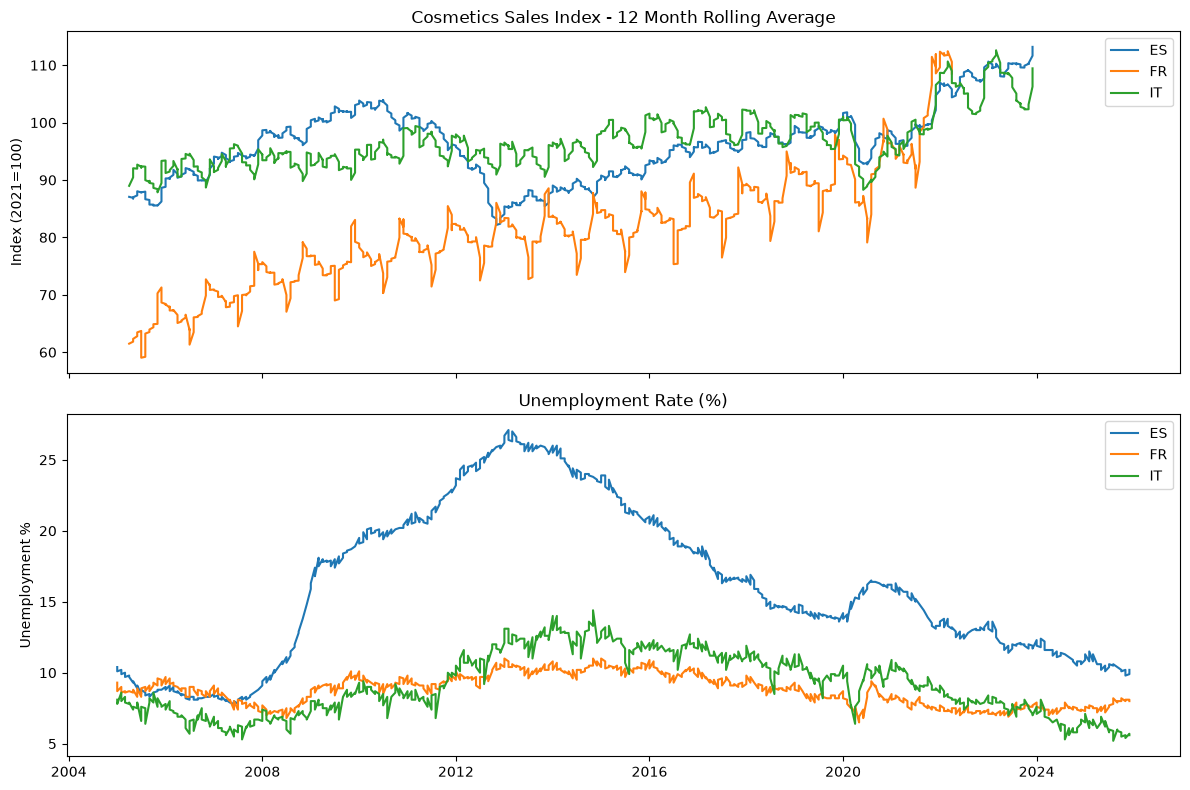

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)
for country in cosmetics['geo'].unique():
    subset=cosmetics[cosmetics['geo']==country].sort_values('TIME_PERIOD')
    rolling=subset['OBS_VALUE'].rolling(window=12).mean()
    ax1.plot(subset['TIME_PERIOD'], rolling,label=country)
    
ax1.set_title("Cosmetics Sales Index - 12 Month Rolling Average")
ax1.set_ylabel("Index (2021=100)")
ax1.legend()

for country in ['ES', 'FR', 'IT']:
    subset=unemp[unemp['geo']==country].sort_values('TIME_PERIOD')
    ax2.plot(subset['TIME_PERIOD'], subset['OBS_VALUE'], label=country) 
ax2.set_title("Unemployment Rate (%)")
ax2.set_ylabel("Unemployment %")
ax2.legend()

plt.tight_layout()
plt.savefig("images/lipstick_effect.png", dpi=150)
plt.show()

SyntaxError: invalid syntax (2807550382.py, line 1)